# Basics of QC: A practical Workshop

The goal of this workshop is to provide a practical first encounter with quantum computing and to develop an intuition for how quantum algorithms are constructed. Our approach is to start with small computational problems, build simple quantum circuits, experiment with them in Qiskit, and gradually introduce the concepts needed to understand why they work: **“run first, explain later”**. 

A useful mindset is to imagine being a curious learner exploring classical computers several decades ago: rather than starting with modern processors and complex software, you might have asked how a 4-bit adder or a simple multiplier could be constructed from basic logical gates such as AND, OR, and NOT. We will approach quantum computing with the same curiosity, starting from its basic building blocks and exploring how they can be combined to perform computation. The objective is therefore not only to learn how to use quantum circuits, but also to begin thinking about computation from a quantum perspective.

<img src="pix/adder_4bit.png" alt="4-bit adder logic-gate circuit" width="700">

## A First Look at Quantum Computing

- Quantum computing introduces a different way of representing and processing information.
- In classical computing, we work with **bits** and classical operations.
- In quantum computing, we work with **qubits** and quantum operations.
- Our goal today is not to understand all the theory behind quantum computing.
- Instead, we will:
  - start with a very small computational problem,
  - compare a classical and a quantum solution,
  - construct our first quantum circuit,
  - and run it using **Qiskit**.
- The example we will use is called **Deutsch's problem**.

## Deutsch's Problem

- Imagine a very simple function $f$.
- The function accepts only one bit as input:

  $$
  f:\{0,1\}\rightarrow\{0,1\}
  $$

- Therefore, we can ask the function only two possible questions:

  $$
  f(0)=?
  $$

  and

  $$
  f(1)=?
  $$

- The answer to each question can also only be $0$ or $1$.

## What Do We Want to Know?

- We are **not** interested in the individual values of $f(0)$ and $f(1)$.
- We only want to know whether they are the **same or different**.

- If

  $$
  f(0)=f(1)
  $$

  we call the function **constant**.

- If

  $$
  f(0)\neq f(1)
  $$

  we call the function **balanced**.

- Our problem is therefore:

  **Is the unknown function constant or balanced?**

## The Four Possible Functions

| Function | $f(0)$ | $f(1)$ | Type |
|---|---:|---:|---|
| $f_0$ | 0 | 0 | Constant |
| $f_1$ | 1 | 1 | Constant |
| $f_2$ | 0 | 1 | Balanced |
| $f_3$ | 1 | 0 | Balanced |

- These are all the possibilities.
- Two functions are **constant**.
- Two functions are **balanced**.
- We do not know in advance which function we have.

## A Classical Solution

- Suppose the function is hidden from us.
- We can only provide an input and observe its output.
- Such access to a function is often called a **query**.

- First query:

  $$
  f(0)
  $$

- Suppose the answer is $0$.
- Can we already determine whether the function is constant or balanced?

- No.
- We still need to ask:

  $$
  f(1)
  $$

- A deterministic classical solution therefore requires **two queries** in the worst case.

## How Do We Compare Algorithms?

- We often compare algorithms by counting computational operations.
- For example:
  - additions,
  - comparisons,
  - iterations,
  - or executed instructions.

- Comparing classical and quantum algorithms operation-by-operation can be difficult.
- Their computational operations have a different nature.
- A quantum gate, for example, is not directly equivalent to a classical CPU instruction.

- We therefore need a meaningful common unit of comparison.

## Comparing Queries

- For Deutsch's problem, we compare the number of times the unknown function must be accessed.
- We call each access a **query**.

- Classical deterministic solution: **2 queries**.

- Deutsch's quantum solution: **1 query**.

- The interesting question is: 
**How can one query in a quantum circuit provide enough information to distinguish the two cases?**

## Enter Quantum Computing

- To construct the quantum solution, we need a different computational model.
- Instead of classical bits, we use **qubits**.
- Instead of classical operations, we use **quantum gates**.
- A sequence of quantum gates forms a **quantum circuit**.

- Deutsch's algorithm uses only **two qubits**.

- We will first construct and run the circuit.
- Later, we can investigate why it works.

<img src="pix/deutsch_schematic.png" alt="Deutsch's algorithm circuit schematic" width="700">

## Our First Quantum Circuit

- A quantum circuit can be viewed as a sequence of operations applied to qubits.
- We will use two qubits:

  - $q_0$ or $x$: the input qubit
  - $q_1$ or $y$: an additional working qubit

- We will encounter three basic quantum gates:

  - $X$ (note: this is not the same $x$ we put as input)
  - $H$ (Hadamard)
  - CNOT

- For now, **think of them simply as operations that change the state of our qubits**.

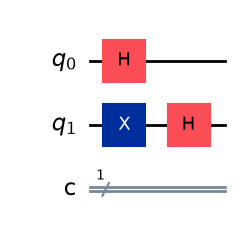

In [5]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 1)

# Preparation
qc.x(1)
qc.h(0)
qc.h(1)

qc.draw("mpl")

## What Are We Looking At?

- The horizontal lines represent our two qubits.
- Time progresses through the circuit from **left to right**.
- Each symbol represents an operation applied to one or more qubits.
- The $X$ and $H$ symbols are **quantum gates**.

- At this point, it is not necessary to understand exactly what every gate does.

- The important idea is: **we are constructing a program by applying a sequence of operations to qubits.**

## Adding the Unknown Function

- Deutsch's algorithm needs access to the unknown function $f$.
- In a quantum circuit, we represent this function using a special quantum operation.
- We call this operation an **oracle**, usually written as $U_f$.

- Different functions require different implementations of $U_f$.
- However, the rest of Deutsch's algorithm remains the same.

- Let us first try a balanced function:

  $$
  f(x)=x
  $$

- Its truth table is:

| $x$ | $f(x)$ |
|---:|---:|
| 0 | 0 |
| 1 | 1 |

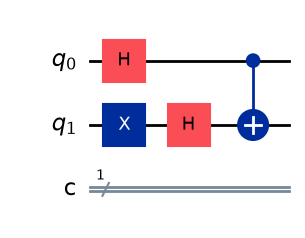

In [6]:
# Oracle for f(x) = x
qc.cx(0, 1)

qc.draw("mpl")

## Completing Deutsch's Circuit

- After applying the oracle, Deutsch's algorithm performs one more operation on the input qubit.
- We then measure that qubit.
- **The measurement gives us an ordinary classical value**: $0$ or $1$.
- The remarkable part is that this single result tells us whether the function is **constant** or **balanced**.

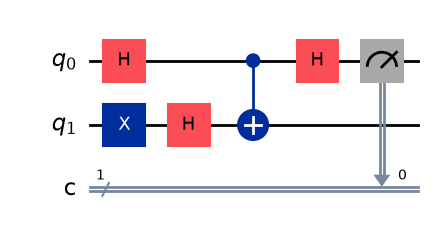

In [7]:
qc.h(0)
qc.measure(0, 0)

qc.draw("mpl")

In [8]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()
print(counts)

{'1': 1000}


## Reading the Result

- Deutsch's algorithm gives a very simple interpretation:

  - measurement $0$ → the function is **constant**
  - measurement $1$ → the function is **balanced**

- We implemented: $f(x)=x$

- This function is balanced because: $f(0)=0,\qquad f(1)=1$

- Therefore, we expect the circuit to produce: $\boxed{1}$

- We have just constructed and executed our first quantum algorithm.

## What Just Happened?

- We started with a simple computational question: **Is $f$ constant or balanced?**

- A deterministic classical algorithm needs to query the function twice in the worst case.
- Deutsch's quantum algorithm queries the quantum oracle only once.
- We implemented the solution using a **two-qubit quantum circuit**.
- We used quantum gates without yet studying all of their mathematical details.
- We executed the circuit using **Qiskit** and interpreted its measurement.

- This gives us our first glimpse of an important idea: **Quantum computing is not simply classical computing with faster hardware. It introduces a different computational model.**

## Where Do We Go From Here?

- We have seen that the circuit works, but many questions remain:

  - What exactly is a **qubit**?
  - What does the $X$ gate do?
  - What does the $H$ gate do?
  - What does a CNOT do?
  - What happens when we use two qubits together?
  - What exactly is the quantum oracle $U_f$?
  - How can Deutsch's algorithm obtain the answer with only one query?
  - What roles do **quantum parallelism** and **phase kickback** play?

- These questions will guide us through the fundamental concepts of quantum computing.

## The X Operation

- Let us start with one of the simplest quantum operations: the **X gate**.
- The $X$ gate operates on a single qubit.
- For now, consider a qubit that is definitely in one of the two states: $\ket{0}$ or $\ket{1}$

- The $X$ gate simply **flips** these two states: $\ket{0} \rightarrow \ket{1}$ and $\ket{1} \rightarrow \ket{0}$
- This is written like: $X\ket{0}=\ket{1}$ and $X\ket{1}=\ket{0}$


## IBM Quantum Platform

- Time to explore quantum circuits in IBM quantum platform
- Explore:
  - how to construct qubits
  - how to add operations
  - how to measure

## X in a Quantum Circuit

- In a quantum circuit, a qubit is represented by a horizontal line.
- A quantum operation is placed on that line.
- The $X$ symbol represents the $X$ gate.
- The circuit is read from **left to right**.

- Starting with $\ket{0}$:

  $$
  \ket{0} \xrightarrow{X} \ket{1}
  $$

- Applying $X$ again:

  $$
  \ket{0} \xrightarrow{X} \ket{1} \xrightarrow{X} \ket{0}
  $$

- Therefore, applying $X$ twice brings us back to the original state:

  $$
  X(X\ket{0})=\ket{0}
  $$

- We can express this more generally as:

  $$
  X^2 = I
  $$

  where $I$ means: **do nothing to the state**.

## But What Exactly Are We Manipulating?

- We have written expressions such as:

  $$
  X\ket{0}=\ket{1}
  $$

  and

  $$
  X^2=I
  $$

- But what exactly are $X$, $I$, $\ket{0}$, and $\ket{1}$?

- In classical computing, we have:
  - bits such as $0$ and $1$,
  - logical operations such as NOT, AND, and OR,
  - Boolean algebra for reasoning about them.

- Do we have something similar for quantum computing?

- **Yes.**

- To understand quantum operations algebraically, we first need to understand how a **qubit** is represented.

## What Is a Qubit?

- A **qubit** is the basic unit of quantum information.

- A classical bit can be in one of two states:

  $$
  0 \quad \mathrm{or} \quad 1
  $$

- A qubit has two corresponding basic states:

  $$
  \ket{0} \quad \mathrm{and} \quad \ket{1}
  $$

- But a qubit is not restricted to only these two states.

- It can also be in a combination of them:

  $$
  \ket{\psi}=\alpha\ket{0}+\beta\ket{1}
  $$

- This combination is called a **superposition**.

## What Are $\alpha$ and $\beta$?

- In

  $$
  \ket{\psi}=\alpha\ket{0}+\beta\ket{1}
  $$

  $\alpha$ and $\beta$ are called **amplitudes**.

- In general, amplitudes can be complex numbers.
  - To keep our first steps simple, in this workshop we will work only with **real numbers**.

- The amplitudes must satisfy: $\alpha^2+\beta^2=1$

- Examples of valid qubit states are:

  $$
  \ket{\psi_1} = \ket{0}
  $$

  $$
  \ket{\psi_2} = \ket{1}
  $$

  $$
  \ket{\psi_3} 
  = 
  \frac{1}{\sqrt{2}}\ket{0}
  +
  \frac{1}{\sqrt{2}}\ket{1}
  $$

## A Qubit Is a Vector

- Mathematically, we represent the state of a qubit using a **vertical vector**.

- We define:

  $$
  \ket{0}
  =
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  $$

  and

  $$
  \ket{1}
  =
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  $$

- These two vectors are called the **computational basis vectors**.

- They provide the building blocks for describing any single-qubit state.

## Dirac Notation

- The notation

  $$
  \ket{\psi}
  $$

  is called **Dirac notation**.

- $\ket{\psi}$ is read as:

  **"ket psi"**

- A ket represents a quantum state.

- For example:

  $$
  \ket{0},\qquad \ket{1},\qquad \ket{\psi}
  $$

- For our purposes, you can initially think of a **ket as a compact notation for a state vector**.

  $$
  \ket{0}
  \longleftrightarrow
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  $$

  $$
  \ket{1}
  \longleftrightarrow
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  $$

## From Ket to Vector

- Consider the general qubit:

  $$
  \ket{\psi}
  =
  \alpha\ket{0}
  +
  \beta\ket{1}
  $$

- Replace the basis states with their vectors:

  $$
  \ket{\psi}
  =
  \alpha
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  +
  \beta
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  $$

- Therefore:

  $$
  \ket{\psi}
  =
  \begin{bmatrix}
  \alpha\\
  \beta
  \end{bmatrix}
  $$

- So a single-qubit state can be represented by a two-dimensional vector.

## Then What Is a Quantum Gate?

- Now we know what a qubit is mathematically:
**a state represented by a vector.**

- What should an operation such as $X$ be?
  - We need something that can transform one vector into another.

- For example:

  $$
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  \quad\longrightarrow\quad
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  $$

- In linear algebra, we can perform such transformations using **matrices**.

- This gives us an important connection: **quantum states are vectors, and quantum gates are matrices.**

## X Is a Matrix

- The $X$ gate is represented by the matrix:

  $$
  X=
  \begin{bmatrix}
  0 & 1\\
  1 & 0
  \end{bmatrix}
  $$

- Recall that:

  $$
  \ket{0}
  =
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  $$

- Let us apply $X$:

  $$
  X\ket{0}
  =
  \begin{bmatrix}
  0 & 1\\
  1 & 0
  \end{bmatrix}
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  $$

- The result is:

  $$
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  =
  \ket{1}
  $$

- Therefore:

  $$
  X\ket{0}=\ket{1}
  $$

## X Transforms Quantum States

- We can do the same calculation with $\ket{1}$:

  $$
  X\ket{1}
  =
  \begin{bmatrix}
  0 & 1\\
  1 & 0
  \end{bmatrix}
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  =
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  =
  \ket{0}
  $$

- We can now understand our original rule algebraically:

  $$
  X\ket{0}=\ket{1}
  $$

  $$
  X\ket{1}=\ket{0}
  $$

- $X$ is not just a symbol meaning "flip": **It is a mathematical transformation that maps one quantum state to another.**

## And What Is $I$?

- Earlier we wrote:

  $$
  X^2=I
  $$

- $I$ is the **identity operation**.

- Its matrix is:

  $$
  I=
  \begin{bmatrix}
  1 & 0\\
  0 & 1
  \end{bmatrix}
  $$

- Applying $I$ does not change the state:

  $$
  I\ket{\psi}=\ket{\psi}
  $$

- Therefore, saying

  $$
  X^2=I
  $$

  means that applying $X$ twice is equivalent to doing nothing.

- For example:

  $$
  \ket{0}
  \xrightarrow{X}
  \ket{1}
  \xrightarrow{X}
  \ket{0}
  $$

## Our Quantum Algebra Is Taking Shape

- We now have three important pieces:

  **Quantum states**

  $$
  \ket{\psi}
  =
  \begin{bmatrix}
  \alpha\\
  \beta
  \end{bmatrix}
  $$

  **Quantum operations**

  $$
  X,\ I,\ \ldots
  $$

  **Transformation**

  $$
  \ket{\psi'}
  =
  X\ket{\psi}
  $$

- In simple terms:

  **vector in → quantum operation → vector out**

- Or:

  **quantum state → quantum gate → new quantum state**

- This gives us an algebraic language for reasoning about quantum circuits.

## Can Any Matrix Be a Quantum Gate?

- We have learned that:
  - a quantum state can be represented by a **vector**,
  - and a quantum gate can be represented by a **matrix**.

- This may suggest a simple idea:
**If a quantum gate is just a matrix, can we build any operation we want by choosing an appropriate matrix?**

- The answer is:
**Yes and No.**

- Yes, matrices give us a powerful way to define transformations.

- But no, **not every matrix represents a valid quantum operation**.

- Quantum operations must satisfy certain conditions.

## One Important Condition: Reversibility

- One important property of quantum operations is **reversibility**.

- If a quantum gate transforms

  $$
  \ket{\psi} \rightarrow \ket{\phi}
  $$

  it must be possible to apply another valid operation and recover the original state:

  $$
  \ket{\phi} \rightarrow \ket{\psi}
  $$

- In other words, the operation must not destroy the information needed to reconstruct the input.

- Knowing the output must be sufficient to determine the input.

## Is X Reversible?

- If we know that the output is $\ket{1}$, we know that the input was $\ket{0}$.

- If we know that the output is $\ket{0}$, we know that the input was $\ket{1}$.

- No information has been lost.

- In fact, applying $X$ again reverses the operation:

  $$
  \ket{0}
  \xrightarrow{X}
  \ket{1}
  \xrightarrow{X}
  \ket{0}
  $$

- Therefore: $X^{-1}=X$ which means: The $X$ gate is **reversible**.

## What Would an Irreversible Operation Look Like?

- Imagine an operation $A$ that does this:

  $$
  A\ket{0}=\ket{0}
  $$

  $$
  A\ket{1}=\ket{0}
  $$

- Both possible inputs produce the **same output**.

- Now suppose we only see: $\ket{0}$

- What was the input? $\ket{0}$ or $\ket{1}$?
  - We cannot know.

- Information about the original state has been lost.
  - Therefore, this operation is **not reversible**.

## A Matrix That Is Not a Quantum Gate

- We could try to represent the previous operation with:

  $$
  A=
  \begin{bmatrix}
  1 & 1\\
  0 & 0
  \end{bmatrix}
  $$

- Applying it to $\ket{0}$ gives:

  $$
  A\ket{0}
  =
  \begin{bmatrix}
  1 & 1\\
  0 & 0
  \end{bmatrix}
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  =
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  =
  \ket{0}
  $$

- Applying it to $\ket{1}$ also gives:

  $$
  A\ket{1}
  =
  \begin{bmatrix}
  1 & 1\\
  0 & 0
  \end{bmatrix}
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  =
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  =
  \ket{0}
  $$

- Two different input states have been mapped to the same state.

- We cannot reverse this transformation.

- Therefore, $A$ is **not a valid quantum gate**.

## Not Every Matrix Is a Quantum Gate

- We have discovered an important restriction: **A quantum gate cannot be represented by just any matrix.**

- A valid quantum gate must preserve quantum information and be reversible.

- Mathematically, quantum gates are represented by a special class of matrices called **unitary matrices**.

- For now, the important intuition is: **A valid quantum gate must allow us to go backward.**

- Later, we will see that this requirement becomes especially interesting **when we try to represent ordinary classical functions as quantum operations**.

## There Is Another Problem

- We have seen that the matrix

  $$
  A=
  \begin{bmatrix}
  1 & 1\\
  0 & 0
  \end{bmatrix}
  $$

  is not reversible.

- But there is another reason why this matrix cannot represent a quantum gate.

- Remember that a valid qubit

  $$
  \ket{\psi}=\alpha\ket{0}+\beta\ket{1}
  $$

  must satisfy:

  $$
  \alpha^2+\beta^2=1
  $$

- We call this condition **normalization**.

## Quantum Gates Must Preserve Normalization

- Consider the valid quantum state:

  $$
  \ket{+}
  =
  \frac{1}{\sqrt{2}}
  \begin{bmatrix}
  1\\
  1
  \end{bmatrix}
  $$

- Its normalization is:

  $$
  \left(\frac{1}{\sqrt{2}}\right)^2
  +
  \left(\frac{1}{\sqrt{2}}\right)^2
  =1
  $$

- Now apply our matrix $A$:

  $$
  A\ket{+}
  =
  \begin{bmatrix}
  1 & 1\\
  0 & 0
  \end{bmatrix}
  \frac{1}{\sqrt{2}}
  \begin{bmatrix}
  1\\
  1
  \end{bmatrix}
  =
  \begin{bmatrix}
  \sqrt{2}\\
  0
  \end{bmatrix}
  $$

- But now:

  $$
  (\sqrt{2})^2+0^2=2
  $$

- The result is **not normalized**.

- Therefore, $A$ does not transform every valid quantum state into another valid quantum state.

## Two Important Requirements

- We have now seen two important properties that quantum gates must have:

  1. They must be **reversible**.
  2. They must **preserve normalization** for any valid quantum state.

- The special matrices that satisfy the requirements of quantum gates are called **unitary matrices**.

- Formally, a unitary matrix $U$ satisfies:

  $$
  U^\dagger U=I
  $$

- We will not explore this condition in more depth in this introductory workshop.

- For our purposes, remember the intuition:
**A quantum gate transforms a valid quantum state into another valid quantum state without losing information.**

- The gates we use in this workshop, including $X$, $H$, and CNOT, satisfy these requirements.

## Let's Take Another Look at $\ket{+}$

- We briefly encountered this state earlier: $\ket{+}$

- We will see $\ket{+}$ many times in quantum computing.

- So, before moving on, let's get comfortable with the notation and play with it algebraically.

- Remember: $\ket{+}$ is just a name for a particular quantum state.

- **Question:** Can you write $\ket{+}$ using the basis states $\ket{0}$ and $\ket{1}$?

## Writing $\ket{+}$ in the Basis States

- The state $\ket{+}$ is defined as:

  $$
  \ket{+}
  =
  \frac{1}{\sqrt{2}}
  \left(
  \ket{0}+\ket{1}
  \right)
  $$

- Or equivalently:

  $$
  \ket{+}
  =
  \frac{1}{\sqrt{2}}\ket{0}
  +
  \frac{1}{\sqrt{2}}\ket{1}
  $$

- Both $\ket{0}$ and $\ket{1}$ are present in the state.

- We say that the qubit is in a **superposition** of $\ket{0}$ and $\ket{1}$.

- The numbers multiplying the basis states are their **amplitudes**. Check if the condition holds.

## $\ket{+}$ as a Vector

- We already know:

  $$
  \ket{0}
  =
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix},
  \qquad
  \ket{1}
  =
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  $$

- Therefore:

  $$
  \ket{+}
  =
  \frac{1}{\sqrt{2}}
  \begin{bmatrix}
  1\\
  0
  \end{bmatrix}
  +
  \frac{1}{\sqrt{2}}
  \begin{bmatrix}
  0\\
  1
  \end{bmatrix}
  $$

- Which gives:

  $$
  \ket{+}
  =
  \frac{1}{\sqrt{2}}
  \begin{bmatrix}
  1\\
  1
  \end{bmatrix}
  $$

- The ket notation and vector notation describe the **same quantum state**.

## Exercise: Apply $X$ to $\ket{+}$

- We know how $X$ acts on the basis states:

  $$
  X\ket{0}=\ket{1}
  $$

  $$
  X\ket{1}=\ket{0}
  $$

- But what happens if the input is not simply $\ket{0}$ or $\ket{1}$?

- Calculate:

  $$
  X\ket{+}
  $$

- Start by replacing $\ket{+}$ with its definition:

  $$
  X\ket{+}
  =
  X
  \left(
  \frac{1}{\sqrt{2}}\ket{0}
  +
  \frac{1}{\sqrt{2}}\ket{1}
  \right)
  $$

- **Can we apply $X$ separately to the two components?**

## Quantum Operations Are Linear

- Yes. Quantum operations are **linear**.

- This means that if:

  $$
  \ket{\psi}
  =
  \alpha\ket{0}+\beta\ket{1}
  $$

  then:

  $$
  X\ket{\psi}
  =
  \alpha X\ket{0}
  +
  \beta X\ket{1}
  $$

- In simple terms: **the operation can be distributed over the components of a superposition.**

- This property is called **linearity**.

- Linearity is one of the most important mathematical properties we will use when manipulating quantum states.

## Exercise: Continue the Calculation

- We had:

  $$
  X\ket{+}
  =
  X
  \left(
  \frac{1}{\sqrt{2}}\ket{0}
  +
  \frac{1}{\sqrt{2}}\ket{1}
  \right)
  $$

- Using linearity:

  $$
  X\ket{+}
  =
  \frac{1}{\sqrt{2}}X\ket{0}
  +
  \frac{1}{\sqrt{2}}X\ket{1}
  $$

- We already know:

  $$
  X\ket{0}=\ket{1}
  \qquad
  X\ket{1}=\ket{0}
  $$

- **Complete the calculation.**

- What state do you obtain?

- Did applying $X$ actually change $\ket{+}$?

## A Useful Algebraic Tool

- We have just used an important pattern:

  1. Write the quantum state in terms of its basis states.
  2. Distribute the quantum operation using **linearity**.
  3. Apply the operation to each basis state.
  4. Simplify the result.

- For example:

  $$
  X
  \left(
  \alpha\ket{0}+\beta\ket{1}
  \right)
  =
  \alpha X\ket{0}+\beta X\ket{1}
  $$

- We will use this kind of algebraic manipulation repeatedly.

- It will become especially useful when we work with:
  - the $H$ gate,
  - multiple qubits,
  - CNOT,
  - and eventually the Deutsch algorithm.

---------------------------

## Another Useful State: $\ket{-}$

- We have introduced:

  $$
  \ket{+}
  =
  \frac{1}{\sqrt{2}}
  \left(
  \ket{0}+\ket{1}
  \right)
  $$

- Another state that we will encounter frequently is:

  $$
  \ket{-}
  =
  \frac{1}{\sqrt{2}}
  \left(
  \ket{0}-\ket{1}
  \right)
  $$

- It looks very similar to $\ket{+}$, but notice the **minus sign**.

- **Exercise 1:** Unfold $\ket{-}$ into its basis states and write it as a vertical vector.

- **Exercise 2:** Apply $X$ to $\ket{-}$:

  $$
  X\ket{-}=?
  $$

- Use linearity:

  $$
  X
  \left(
  \frac{1}{\sqrt{2}}\ket{0}
  -
  \frac{1}{\sqrt{2}}\ket{1}
  \right)
  $$

- Can you express the final result again using $\ket{-}$?

---------------------------

## Building Our X Table

- We now know how $X$ behaves on several useful quantum states.

| Input | Output |
|:---:|:---:|
| $\ket{0}$ | $\ket{1}$ |
| $\ket{1}$ | $\ket{0}$ |
| $\ket{+}$ | $\ket{+}$ |
| $\ket{-}$ | **?** |

- Complete the last row using your result from the previous exercise.

- Notice that we are gradually building a **lookup table for the behavior of $X$**.

- Once we know these transformation rules, we do not need to perform matrix multiplication every time.

- Instead, we can manipulate quantum states directly using rules such as:

  $$
  X\ket{0}=\ket{1}
  \qquad
  X\ket{1}=\ket{0}
  \qquad
  X\ket{+}=\ket{+}
  \qquad
  X\ket{-}=?
  $$

- **This will make our calculations shorter and easier to follow as our quantum circuits become more complex.**